This notebook demonstrates a simple linear regression analysis using [Python/R] to model Salary based on Years of Experience.

In [94]:
import pandas as pd
dataset = pd.read_csv("../regression_data.csv")
dataset.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


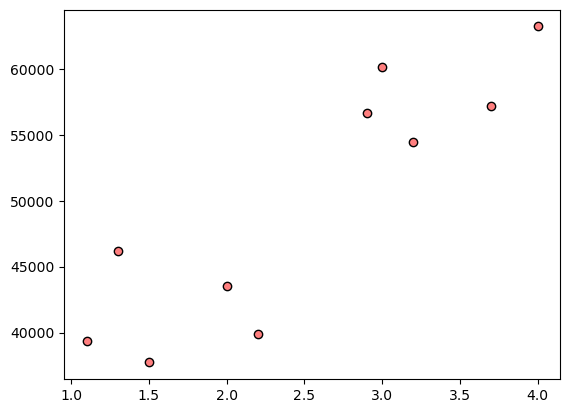

In [95]:
import matplotlib.pyplot as plt
plt.scatter(dataset["YearsExperience"], dataset["Salary"], color=(1, 0, 0, 0.5), edgecolors="k")

In [96]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(dataset[["YearsExperience"]], dataset[["Salary"]])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [97]:
intercept = model.intercept_[0] if hasattr(model.intercept_, '__len__') else model.intercept_
coefs = model.coef_[0] if model.coef_.ndim > 1 else model.coef_

equation = f"y = {intercept:.4f}"
for i, c in enumerate(coefs):
    equation += f" + ({c:.4f} * x{i+1})"

print(equation)

y = 29203.5227 + (8285.2921 * x1)


In [98]:
import numpy as np

In [99]:
slope = np.ravel(model.coef_)[0]
intercept = np.ravel(model.intercept_)[0]

print(type(slope), slope)
print(type(intercept), intercept)

<class 'numpy.float64'> 8285.292099903527
<class 'numpy.float64'> 29203.52267124022


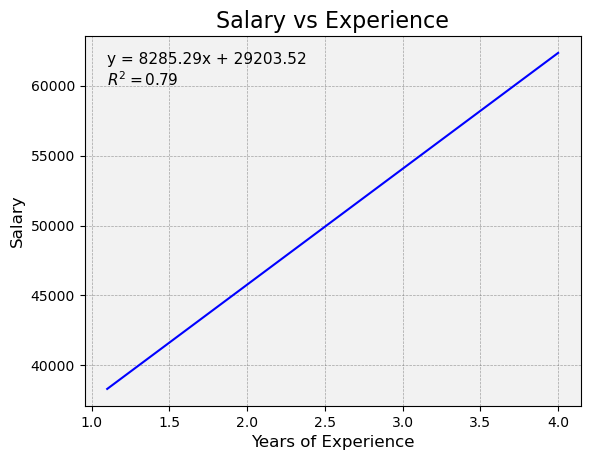

In [100]:
plt.plot(dataset["YearsExperience"], model.predict(dataset[["YearsExperience"]]), color="blue")
plt.grid(True, color="gray", linestyle="--", linewidth=0.5, alpha=0.7, zorder=0)
plt.gca().set_facecolor(("gray", 0.1))
plt.title("Salary vs Experience", fontsize=16)
plt.xlabel("Years of Experience", fontsize=12)
plt.ylabel("Salary", fontsize=12)
plt.text(
    1.1,
    60000,
    f"y = {slope:.2f}x + {intercept:.2f}\n$R^2 = 0.79$",
    fontsize=11
)
plt.show()

In [101]:
model.score(dataset[["YearsExperience"]], dataset[["Salary"]])  # R-squared

0.7851515863136573